# Assignment 4: Unsupervised Learning; Clustering and Recommendation

Group 70: Michael Massaad (300293612) & Gabriel Zohrob (300309391)

Work Split:
- Gabriel Zohrob: Worked on data preparation and implemented Study 1 and 2

- Michael Massaad: Worked on data preparation and implemented Study 3 and 4

## Description of The Movies Dataset

Link: https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset

Author: Rounak Banik

Purpose: This dataset was originally assembled as part of a data science capstone project with the goal of performing extensive exploratory data analysis on movie data to better understand trends in the film industry. It was also designed to support the development of different types of recommendation systems by combining movie metadata with user rating data from the MovieLens dataset.

The dataset includes two main components:
- movie metadata, such as title, genres, overview, popularity, runtime, budget, revenue, and rating statistics (Study 1, 2, 3)
- user rating data, which captures how individual users rate different movies (Study 4)

Shape:
- movies_metadata.csv: 45,466 rows × 24 columns
- ratings_small.csv: 100,004 rows × 4 columns

Features: 

For the movies_metadata.csv:
- adult: Indicates whether the movie is adult content (TRUE/FALSE) – Categorical
- belongs_to_collection: Collection or franchise the movie belongs to (JSON structure) – Categorical
- budget: Production budget of the movie in USD – Numerical
- genres: List of genres associated with the movie (e.g., Action, Comedy) – Categorical
- homepage: Official website URL of the movie – Categorical
- id: Unique identifier for each movie – Numerical
- imdb_id: IMDb identifier for the movie – Categorical
- original_language: Original language of the movie (e.g., en, fr) – Categorical
- original_title: Original title of the movie – Categorical
- overview: Summary or description of the movie’s plot – Categorical
- popularity: Popularity score assigned to the movie – Numerical
- poster_path: Path to the movie’s poster image – Categorical
- production_companies: Companies involved in producing the movie – Categorical
- production_countries: Countries where the movie was produced – Categorical
- release_date: Date the movie was released – Categorical
- revenue: Revenue generated by the movie in USD – Numerical
- runtime: Duration of the movie in minutes – Numerical
- spoken_languages: Languages spoken in the movie – Categorical
- status: Release status of the movie (e.g., Released, Rumored) – Categorical
- tagline: Promotional tagline or slogan of the movie – Categorical
- title: Title of the movie – Categorical
- video: Indicates if a video is associated with the movie (TRUE/FALSE) – Categorical
- vote_average: Average rating given to the movie – Numerical
- vote_count: Total number of user votes – Numerical

For the ratings_small.csv: 
- userId: Unique identifier for each user – Numerical
- movieId: Unique identifier for each movie (links to movies dataset) – Numerical
- rating: Rating given by the user to the movie (typically from 0.5 to 5.0) – Numerical
- timestamp: Time at which the rating was given (Unix timestamp format) – Numerical

Explanation: 
This dataset was chosen because it provides both movie metadata and user ratings, allowing for a wide range of data analysis tasks. It enables the exploration of relationships between movie attributes (such as budget, popularity, and genres) and user behavior (ratings). Additionally, it supports tasks such as predicting movie success and building recommendation systems, making it well-suited for this assignment.


## Dataset Loading

In [282]:
# ===============================
# Imports
# ===============================
import pandas as pd
import numpy as np
import ast

# Optional display settings for easier notebook viewing
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [283]:
# ===============================
# Load datasets
# ===============================
movies_url = "https://raw.githubusercontent.com/gabrielzohrob/CSI-4142---Assignment-4/refs/heads/main/movies_metadata.csv"
ratings_url = "https://raw.githubusercontent.com/gabrielzohrob/CSI-4142---Assignment-4/refs/heads/main/ratings_small.csv"

movies = pd.read_csv(movies_url, low_memory=False)
ratings = pd.read_csv(ratings_url)

print("movies_metadata shape:", movies.shape)
print("ratings_small shape:", ratings.shape)

movies_metadata shape: (45466, 24)
ratings_small shape: (100004, 4)


## Data cleaning

### Data Inspection

In [284]:
# ===============================
# Basic inspection
# ===============================

print("Movies columns:")
print(movies.columns.tolist())

print("\nRatings columns:")
print(ratings.columns.tolist())

print("\nMovies preview:")
display(movies.head())

print("\nRatings preview:")
display(ratings.head())

Movies columns:
['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count']

Ratings columns:
['userId', 'movieId', 'rating', 'timestamp']

Movies preview:


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', 'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg', 'backdrop_path': '/9FBwqcd9IRruEDUrTdcaafOMKUq.jpg'}",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circum...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fantasy'}, {'id': 10751, 'name': 'Family'}]",NaN,8844,tt0113497,en,Jumanji,"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game for 26 years -- in...",17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'name': 'Teitler Film', 'id': 2550}, {'name': 'Interscope Communications', 'id': 10201}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso_639_1': 'fr', 'name': 'Français'}]",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collection', 'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet.jpg', 'backdrop_path': '/hypTnLot2z8wpFS7qwsQHW1uV8u.jpg'}",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, 'name': 'Comedy'}]",NaN,15602,tt0113228,en,Grumpier Old Men,"A family wedding reignites the ancient feud between next-door neighbors and fishing buddies John and Max. Meanwhile, a sultry Italian divorcée opens a restaurant at the local bait shop, alarming t...",11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name': 'Lancaster Gate', 'id': 19464}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for Love.,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'name': 'Drama'}, {'id': 10749, 'name': 'Romance'}]",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the women are holding their breath, waiting for the elusive ""good man"" to break a string of less-than-stellar lovers. Friends and confidants Vannah, Bernie, ...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,"[{'name': 'Twentieth Century Fox Film Corporation', 'id': 306}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself... and never let you forget it.,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Collection', 'poster_path': '/nts4iOmNnq7GNicycMJ9pSAn204.jpg', 'backdrop_path': '/7qwE57OVZmMJChBpLEbJEmzUydk.jpg'}",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,"Just when George Banks has recovered from his daughter's wedding, he receives the news that she's pregnant ... and that George's wife, Nina, is expecting too. He was planning on selling their home...",8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,"[{'name': 'Sandollar Productions', 'id': 5842}, {'name': 'Touchstone Pictures', 'id': 9195}]","[{'iso_3166_1': '


Ratings preview:


,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [285]:
# ===============================
# Inspect data types
# ===============================
dtypes_table = pd.DataFrame({
    "Column": movies.columns,
    "Data Type": movies.dtypes.values
})

dtypes_table

,Column,Data Type
0,adult,str
1,belongs_to_collection,str
2,budget,str
3,genres,str
4,homepage,str
5,id,str
6,imdb_id,str
7,original_language,str
8,original_title,str
9,overview,str


In [286]:
# ===============================
# Check missing values
# ===============================
missing_table = pd.DataFrame({
    "Column": movies.columns,
    "Missing Values": movies.isnull().sum().values
})

missing_table = missing_table.sort_values(by="Missing Values", ascending=False)

missing_table

,Column,Missing Values
1,belongs_to_collection,40972
4,homepage,37684
19,tagline,25054
9,overview,954
11,poster_path,386
16,runtime,263
18,status,87
14,release_date,87
6,imdb_id,17
7,original_language,11


In [287]:
# ===============================
# Check problematic 'id' column
# ===============================
# Try converting id to numeric to see errors
invalid_ids = pd.to_numeric(movies['id'], errors='coerce').isnull().sum()

id_check_table = pd.DataFrame({
    "Check": ["Invalid ID values (non-numeric)"],
    "Count": [invalid_ids]
})

id_check_table

,Check,Count
0,Invalid ID values (non-numeric),3


### Data cleaning

In [288]:
# ===============================
# Fix 'id' column (CRITICAL STEP)
# ===============================

# Convert id to numeric (invalid values → NaN)
movies['id'] = pd.to_numeric(movies['id'], errors='coerce')

# Count how many invalid IDs we have
invalid_ids = movies['id'].isnull().sum()
print("Invalid ID rows:", invalid_ids)

# Drop rows with invalid IDs
movies = movies.dropna(subset=['id'])

# Convert to integer
movies['id'] = movies['id'].astype(int)

# Verify
print("New movies shape:", movies.shape)

Invalid ID rows: 3
New movies shape: (45463, 24)


The `id` column was cleaned to ensure it can be reliably used as a unique identifier for each movie. Since some entries contained non-numeric values, the column was converted to a numeric format and invalid rows were removed. A total of **3 rows with invalid IDs** were identified and dropped, resulting in a cleaned dataset with **45,463 rows and 24 columns**. This step is essential for correctly linking the movies dataset with the ratings dataset in later stages of the analysis.


In [289]:
# ===============================
# Convert columns to numeric
# ===============================

# Convert popularity to numeric
movies['popularity'] = pd.to_numeric(movies['popularity'], errors='coerce')

# Convert budget to numeric
movies['budget'] = pd.to_numeric(movies['budget'], errors='coerce')

The popularity and budget columns were originally stored as strings and were converted to numeric format using pd.to_numeric. Invalid values were coerced to missing values to ensure proper numerical analysis.

In [290]:
# ===============================
# Drop high-missing / irrelevant columns
# ===============================
columns_to_drop = [
    'belongs_to_collection',
    'homepage',
    'tagline',
    'poster_path'
]

movies = movies.drop(columns=columns_to_drop)

print("New shape after dropping columns:", movies.shape)

New shape after dropping columns: (45463, 20)


In [291]:
# =====================
# Handle missing values
# =====================

# Before
missing_before = movies[['overview', 'runtime', 'release_date']].isnull().sum()

# Cleaning
movies[['overview', 'runtime', 'release_date']] = movies[['overview', 'runtime', 'release_date']].fillna({
    'overview': '',
    'runtime': movies['runtime'].median(),
    'release_date': 'Unknown'
})

# After
missing_after = movies[['overview', 'runtime', 'release_date']].isnull().sum()

# Combine results
pd.concat([missing_before.rename("Before"), missing_after.rename("After")], axis=1)

,Before,After
overview,954,0
runtime,260,0
release_date,87,0


Missing values in key features were handled using appropriate imputation methods. The overview column was filled using constant imputation (empty string), as it represents text data. The runtime column was imputed using the median value, which is robust to outliers in numerical data. The release_date column was filled using a placeholder value (“Unknown”). The table above shows that missing values in these columns were successfully reduced to zero.

### Feature Engineering

In [292]:
# ===============================
# Parse genres column
# ===============================
import ast

# Function to safely extract genre names
def parse_genres(text):
    try:
        genres_list = ast.literal_eval(text)
        return [genre['name'] for genre in genres_list]
    except:
        return []

# Apply parsing
movies['genres'] = movies['genres'].apply(parse_genres)

# Preview result
movies[['title', 'genres']].head()

,title,genres
0,Toy Story,"[Animation, Comedy, Family]"
1,Jumanji,"[Adventure, Fantasy, Family]"
2,Grumpier Old Men,"[Romance, Comedy]"
3,Waiting to Exhale,"[Comedy, Drama, Romance]"
4,Father of the Bride Part II,[Comedy]


The genres column was originally stored as a JSON-like string, making it unusable for analysis. It was parsed into a structured list format using ast.literal_eval, and only the genre names were extracted.

In [293]:
# ===============================
# Encode genres using multi-label binary encoding
# ===============================
from sklearn.preprocessing import MultiLabelBinarizer

# Shape BEFORE encoding
print("Shape before encoding:", movies.shape)

# Initialize encoder
mlb = MultiLabelBinarizer()

# Transform genres
genres_encoded = pd.DataFrame(
    mlb.fit_transform(movies['genres']),
    columns=mlb.classes_,
    index=movies.index
)

# Merge with original dataset
movies = pd.concat([movies, genres_encoded], axis=1)

# Shape AFTER encoding
print("Shape after encoding:", movies.shape)

Shape before encoding: (45463, 20)
Shape after encoding: (45463, 40)


The genres feature was encoded using multi-label binary encoding, where each unique genre was converted into a separate binary column. As a result, the dataset expanded from 20 to 40 features, while the number of observations remained unchanged.

### EDA

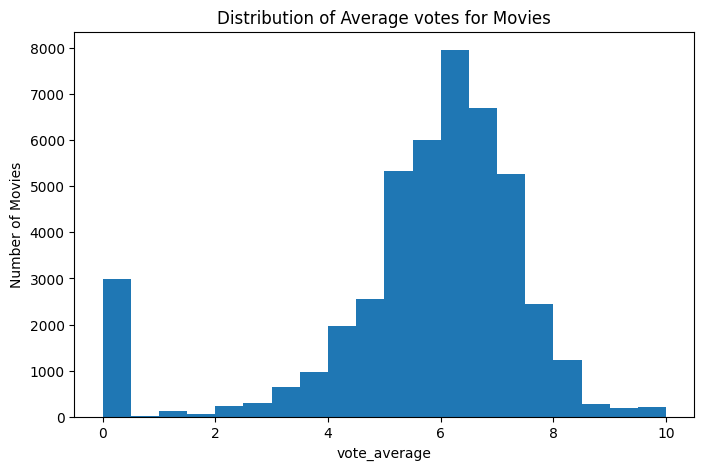

In [294]:
# ===============================
# EDA 1 — Distribution of Ratings
# ===============================
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(movies['vote_average'], bins=20)

plt.title("Distribution of Average votes for Movies")
plt.xlabel("vote_average")
plt.ylabel("Number of Movies")

plt.show()

In [295]:
# ===============================
# Percentage of movies by rating (2 decimal places)
# ===============================

movies['rating_rounded'] = movies['vote_average'].round()

rating_counts = movies['rating_rounded'].value_counts().sort_index()

rating_percentages = ((rating_counts / len(movies)) * 100).round(2)

rating_distribution = pd.DataFrame({
    'Count': rating_counts,
    'Percentage (%)': rating_percentages
})

rating_distribution

,Count,Percentage (%)
rating_rounded,,
0.0,3011,6.62
1.0,129,0.28
2.0,413,0.91
3.0,817,1.80
4.0,3506,7.71
5.0,7343,16.15
6.0,15675,34.48
7.0,10229,22.50
8.0,3831,8.43


The rating distribution shows that the majority of movies fall within the 5–7 range, with ratings of 6 (34.48%) and 7 (22.50%) being the most common. Lower ratings (0–3) and very high ratings (9–10) are relatively rare, indicating that most movies are perceived as average to moderately good rather than extremely poor or exceptional.

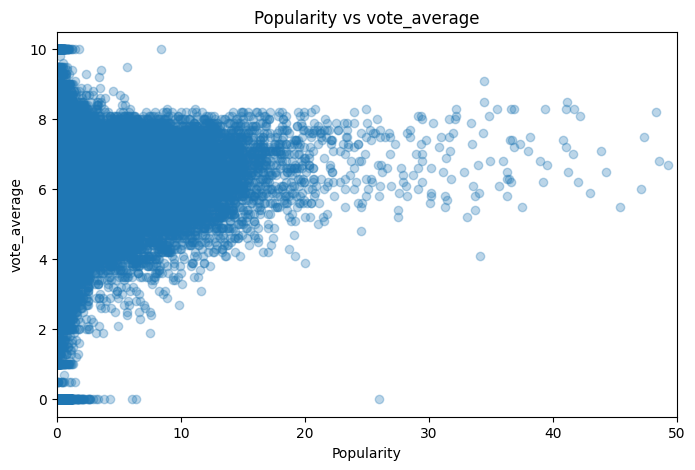

In [296]:
# ===============================
# Prepare data for EDA 2
# ===============================

# Create a copy for analysis
eda2_movies = movies.copy()

# Remove rows with missing values ONLY for this analysis
eda2_movies = eda2_movies.dropna(subset=['popularity', 'vote_average'])

# ===============================
# EDA 2 — Popularity vs Rating
# ===============================
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(eda2_movies['popularity'], eda2_movies['vote_average'], alpha=0.3)

plt.xlim(0, 50)

plt.title("Popularity vs vote_average")
plt.xlabel("Popularity")
plt.ylabel("vote_average")

plt.show()

The scatter plot shows no strong relationship between movie popularity and rating. Most movies cluster between ratings of 5 and 7 across all popularity levels, indicating that higher popularity does not necessarily correspond to higher ratings.

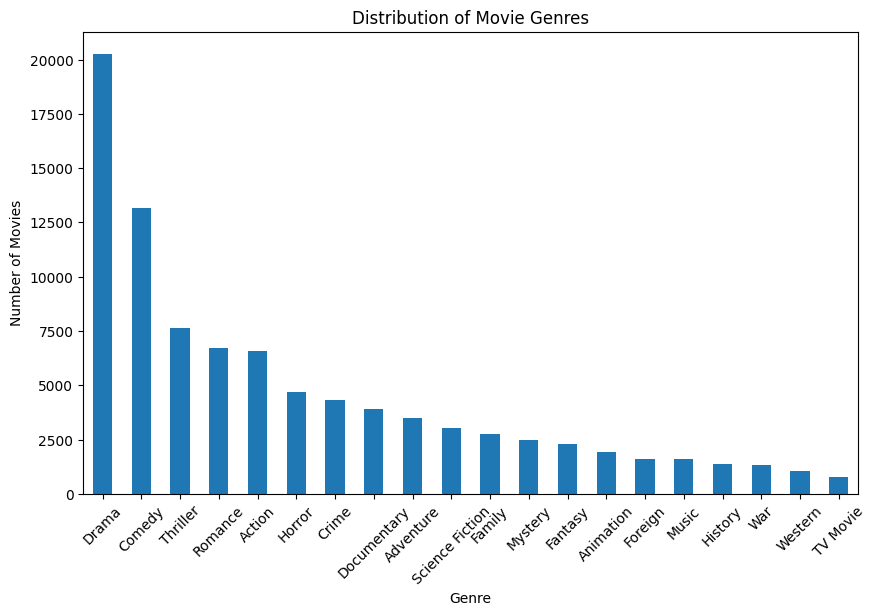

In [297]:
# ===============================
# EDA 3 — Genre Distribution
# ===============================

# Sum each genre column (from encoding step)
genre_counts = movies[mlb.classes_].sum().sort_values(ascending=False)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
genre_counts.plot(kind='bar')

plt.title("Distribution of Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)
plt.show()

In [298]:
# ===============================
# Genre percentage distribution
# ===============================

# Count genres
genre_counts = movies[mlb.classes_].sum()

# Convert to percentage
genre_percentages = ((genre_counts / len(movies)) * 100).round(2)

# Combine into table
genre_distribution = pd.DataFrame({
    'Count': genre_counts,
    'Percentage (%)': genre_percentages
}).sort_values(by='Count', ascending=False)

genre_distribution

,Count,Percentage (%)
Drama,20265,44.57
Comedy,13182,29.00
Thriller,7624,16.77
Romance,6735,14.81
Action,6596,14.51
Horror,4673,10.28
Crime,4307,9.47
Documentary,3932,8.65
Adventure,3496,7.69
Science Fiction,3049,6.71


The genre distribution confirms that Drama is the most prevalent genre, representing 44.57% of the dataset, followed by Comedy (29.00%) and Thriller (16.77%). Other genres such as Romance and Action also appear frequently, while genres like Western (2.29%) and TV Movie (1.69%) are relatively rare.

## Study 1 - Similarity Measures

In [299]:
# ===============================
# Study 1 - Similarity Measures
# Data preparation for this study
# ===============================

import pandas as pd
import numpy as np
import ast
import difflib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Create a separate copy so Study 1 does not affect the main dataframe
study1_movies = movies.copy()

# Keep only the columns needed for Study 1
study1_movies = study1_movies[[
    'title',
    'genres',
    'runtime',
    'budget',
    'overview',
    'popularity'
]].copy()

# Ensure text columns have no missing values
study1_movies['title'] = study1_movies['title'].fillna('')
study1_movies['overview'] = study1_movies['overview'].fillna('')

# Ensure numeric columns are numeric
study1_movies['runtime'] = pd.to_numeric(study1_movies['runtime'], errors='coerce')
study1_movies['budget'] = pd.to_numeric(study1_movies['budget'], errors='coerce')
study1_movies['popularity'] = pd.to_numeric(study1_movies['popularity'], errors='coerce')

# If genres are still stored as strings, parse them into Python lists
def parse_genres_if_needed(x):
    if isinstance(x, list):
        return x
    try:
        return [item['name'] for item in ast.literal_eval(x)]
    except:
        return []

study1_movies['genres'] = study1_movies['genres'].apply(parse_genres_if_needed)

# Remove rows with missing titles
study1_movies = study1_movies[study1_movies['title'].str.strip() != ''].copy()

print("Study 1 dataset shape:", study1_movies.shape)
study1_movies.head()

Study 1 dataset shape: (45460, 6)


,title,genres,runtime,budget,overview,popularity
0,Toy Story,"[Animation, Comedy, Family]",81.0,30000000,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circum...",21.946943
1,Jumanji,"[Adventure, Fantasy, Family]",104.0,65000000,"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game for 26 years -- in...",17.015539
2,Grumpier Old Men,"[Romance, Comedy]",101.0,0,"A family wedding reignites the ancient feud between next-door neighbors and fishing buddies John and Max. Meanwhile, a sultry Italian divorcée opens a restaurant at the local bait shop, alarming t...",11.712900
3,Waiting to Exhale,"[Comedy, Drama, Romance]",127.0,16000000,"Cheated on, mistreated and stepped on, the women are holding their breath, waiting for the elusive ""good man"" to break a string of less-than-stellar lovers. Friends and confidants Vannah, Bernie, ...",3.859495
4,Father of the Bride Part II,[Comedy],106.0,0,"Just when George Banks has recovered from his daughter's wedding, he receives the news that she's pregnant ... and that George's wife, Nina, is expecting too. He was planning on selling their home...",8.387519


A cleaned subset of the movie dataset was created for Study 1 using five attributes: genres, runtime, budget, overview, and title. These attributes were selected to support categorical, numerical, vector-based, and text-based similarity measures.

In [300]:
# ===============================
# Helper function to retrieve a movie by title
# ===============================

def get_movie_row(df, movie_title):
    """
    Return the first matching movie row for a given title.
    Raises an error if the movie is not found.
    """
    matches = df[df['title'] == movie_title]
    
    if matches.empty:
        raise ValueError(f"Movie '{movie_title}' not found in dataset.")
    
    return matches.iloc[0]

In [301]:
# ===============================
# Jaccard similarity for genres
# ===============================

def jaccard_similarity(genres1, genres2):
    """
    Compute Jaccard similarity between two genre lists.
    """
    set1 = set(genres1)
    set2 = set(genres2)

    union = len(set1.union(set2))
    intersection = len(set1.intersection(set2))

    if union == 0:
        return 0.0

    return intersection / union

In [302]:
# ===============================
# Request 1: Top 10 movies with similar genres
# ===============================

def top10_jaccard_genres(df, movie_title):
    """
    Return the Top 10 movies most similar in genre to the target movie.
    Results are ranked by Jaccard similarity (descending),
    then by popularity (descending) as a tie-breaker.
    """
    target = get_movie_row(df, movie_title)

    results = []

    for idx, row in df.iterrows():
        if row['title'] == movie_title:
            continue

        score = jaccard_similarity(target['genres'], row['genres'])

        results.append({
            'title': row['title'],
            'genres': row['genres'],
            'popularity': row['popularity'],
            'jaccard_similarity': round(score, 4)
        })

    results_df = pd.DataFrame(results)

    # Sort by similarity first, then popularity
    results_df = results_df.sort_values(
        by=['jaccard_similarity', 'popularity'],
        ascending=[False, False]
    )

    return results_df.head(10)

In [303]:
# User request 1
request1_results = top10_jaccard_genres(study1_movies, "Toy Story")
request1_results

,title,genres,popularity,jaccard_similarity
45132,The Emoji Movie,"[Comedy, Family, Animation]",33.694599,1.0
4755,"Monsters, Inc.","[Animation, Comedy, Family]",26.419962,1.0
21158,Despicable Me 2,"[Animation, Comedy, Family]",24.823550,1.0
10519,Chicken Little,"[Animation, Family, Comedy]",18.584609,1.0
2996,Toy Story 2,"[Animation, Comedy, Family]",17.547693,1.0
15347,Toy Story 3,"[Animation, Family, Comedy]",16.966470,1.0
21777,Cloudy with a Chance of Meatballs 2,"[Animation, Family, Comedy]",14.412061,1.0
11958,The Simpsons Movie,"[Animation, Comedy, Family]",14.302911,1.0
6794,Looney Tunes: Back in Action,"[Animation, Comedy, Family]",13.666488,1.0
42228,The Boss Baby,"[Animation, Comedy, Family]",13.392824,1.0


Jaccard similarity was applied to the genres attribute by comparing sets of genres for each movie. The results show that the top recommended movies have identical genre combinations (Animation, Comedy, Family), resulting in a similarity score of 1.0. These movies are highly similar in terms of category and are therefore strong recommendations based on genre alone.

In [304]:
# ===============================
# Euclidean distance for runtime
# ===============================

def euclidean_runtime(runtime1, runtime2):
    """
    Compute Euclidean distance between two runtime values.
    For one numerical feature, this is the absolute difference.
    """
    return abs(runtime1 - runtime2)

In [305]:
# ===============================
# Request 2: Top 10 movies with similar runtime
# ===============================

def top10_euclidean_runtime(df, movie_title):
    """
    Return the Top 10 movies with runtime closest to the target movie.
    Results are ranked by Euclidean distance (ascending),
    then by popularity (descending) as a tie-breaker.
    """
    clean_df = df.dropna(subset=['runtime']).copy()
    target = get_movie_row(clean_df, movie_title)

    results = []

    for idx, row in clean_df.iterrows():
        if row['title'] == movie_title:
            continue

        distance = euclidean_runtime(target['runtime'], row['runtime'])

        results.append({
            'title': row['title'],
            'runtime': row['runtime'],
            'popularity': row['popularity'],
            'euclidean_distance': round(distance, 4)
        })

    results_df = pd.DataFrame(results)

    # Sort by smallest distance first
    results_df = results_df.sort_values(
        by=['euclidean_distance', 'popularity'],
        ascending=[True, False]
    )

    return results_df.head(10)

In [306]:
# User request 2
request2_results = top10_euclidean_runtime(study1_movies, "Apollo 13")
request2_results

,title,runtime,popularity,euclidean_distance
44267,War for the Planet of the Apes,140.0,146.161786,0.0
41135,Operation Mekong,140.0,35.972581,0.0
10121,Batman Begins,140.0,28.505341,0.0
42861,The Lost City of Z,140.0,21.791111,0.0
40409,Hacksaw Ridge,140.0,21.037699,0.0
10068,Star Wars: Episode III - Revenge of the Sith,140.0,13.165421,0.0
17827,Warrior,140.0,13.121626,0.0
11757,La Vie en Rose,140.0,11.710507,0.0
15495,The Karate Kid,140.0,11.690781,0.0
4084,Death on the Nile,140.0,11.162277,0.0


Euclidean distance was applied to the runtime attribute. The results show several movies with a distance of 0.0, meaning they have exactly the same runtime as the target movie. These movies are considered identical in duration, and popularity was used as a secondary criterion to rank them.

In [307]:
# ===============================
# Manhattan distance for budget
# ===============================

def manhattan_budget(budget1, budget2):
    """
    Compute Manhattan distance between two budget values.
    For one numerical feature, this is the absolute difference.
    """
    return abs(budget1 - budget2)

In [308]:
# ===============================
# Request 3: Top 10 movies with similar budget
# ===============================

def top10_manhattan_budget(df, movie_title):
    """
    Return the Top 10 movies with budget closest to the target movie.
    Results are ranked by Manhattan distance (ascending),
    then by popularity (descending) as a tie-breaker.
    """
    clean_df = df.dropna(subset=['budget']).copy()
    
    # Budget of 0 is often uninformative, so remove zero-budget rows
    clean_df = clean_df[clean_df['budget'] > 0].copy()

    target = get_movie_row(clean_df, movie_title)

    results = []

    for idx, row in clean_df.iterrows():
        if row['title'] == movie_title:
            continue

        distance = manhattan_budget(target['budget'], row['budget'])

        results.append({
            'title': row['title'],
            'budget': row['budget'],
            'popularity': row['popularity'],
            'manhattan_distance': round(distance, 4)
        })

    results_df = pd.DataFrame(results)

    # Sort by smallest distance first
    results_df = results_df.sort_values(
        by=['manhattan_distance', 'popularity'],
        ascending=[True, False]
    )

    return results_df.head(10)

In [309]:
# User request 3
request3_results = top10_manhattan_budget(study1_movies, "The Matrix")
request3_results

,title,budget,popularity,manhattan_distance
1328,Fight Club,63000000,63.869599,0
3801,World Trade Center,63000000,13.332102,0
1067,Rambo III,63000000,11.624866,0
183,Wyatt Earp,63000000,9.277147,0
5288,Hop,63000000,8.904488,0
219,Jurassic Park,63000000,8.863776,0
2288,Austin Powers in Goldmember,63000000,8.786653,0
1739,Get Carter,63600000,6.047757,600000
3572,Æon Flux,62000000,12.201912,1000000
7624,The Little Prince,64000000,11.376954,1000000


Manhattan distance was used to compare movie budgets. Several movies have a distance of 0, indicating they share the exact same budget as the target movie. Movies with slightly different budgets appear next with small distance values. This shows that budget similarity can effectively group movies with similar production scales.

In [310]:
# ===============================
# Prepare TF-IDF matrix for overview text
# ===============================

# Keep only rows with a usable overview
overview_df = study1_movies.copy()
overview_df = overview_df[overview_df['overview'].str.strip() != ''].copy()

# Reset index so row positions are clean and consistent
overview_df = overview_df.reset_index(drop=True)

# Build TF-IDF vectors from movie overviews
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(overview_df['overview'])

In [311]:
# ===============================
# Request 4: Top 10 movies with similar overview
# ===============================

def top10_cosine_overview(df, movie_title):
    """
    Return the Top 10 movies with most similar plot overview to the target movie.
    Results are ranked by cosine similarity (descending),
    then by popularity (descending) as a tie-breaker.
    If multiple movies share the same title, the first match is used.
    """

    # Find all rows with the requested title
    matches = overview_df[overview_df['title'] == movie_title]

    if matches.empty:
        raise ValueError(f"Movie '{movie_title}' does not have a usable overview.")

    # Use the first matching row
    target_position = matches.index[0]

    # Compute cosine similarity between target movie and all others
    similarities = cosine_similarity(tfidf_matrix[target_position], tfidf_matrix).flatten()

    results = []

    for i, sim_score in enumerate(similarities):
        row = overview_df.iloc[i]

        # Skip the selected movie itself
        if i == target_position:
            continue

        results.append({
            'title': row['title'],
            'overview': row['overview'][:120] + '...' if len(row['overview']) > 120 else row['overview'],
            'popularity': row['popularity'],
            'cosine_similarity': round(float(sim_score), 4)
        })

    results_df = pd.DataFrame(results)

    # Sort by highest similarity first, then popularity
    results_df = results_df.sort_values(
        by=['cosine_similarity', 'popularity'],
        ascending=[False, False]
    )

    return results_df.head(10)

In [312]:
# User request 4
request4_results = top10_cosine_overview(study1_movies, "Titanic")
request4_results

,title,overview,popularity,cosine_similarity
2405,Beyond the Poseidon Adventure,"After ""The Poseidon Adventure"", in which the ship got flipped over by a tidal wave, the ship drifts bottom-up in the sea...",3.276763,0.2833
33360,Lifepod,Lifepod cronicles the trip of eight passengers after the ship they were traveling on blew up on Christmas Eve. Immediate...,1.672776,0.2713
2557,The Legend of 1900,"The story of a virtuoso piano player who lives his entire life aboard an ocean liner. Born and raised on the ship, 1900 ...",7.668214,0.2664
33041,2103: The Deadly Wake,Proxate Corporation recruits a boozy former ship captain and offers him a new identity: Sean Murdoch. His job: to take c...,0.108552,0.2636
37948,Dustbin Baby,"The film follows the story of young teen April whose troubled life began in a dustbin - a new born baby, abandoned and a...",1.253951,0.2545
8383,Action in the North Atlantic,Lieutenant Joe Rossi is 1st Officer on a Liberty Ship in a great convoy bound from Halifax to Murmansk. After German sub...,0.454126,0.2489
35508,Genetic Me,Directed by Pernille Rose Grønkjær.,0.017649,0.2398
4687,Death Ship,Survivors of a tragic shipping collision are rescued by a mysterious black ship which appears out of the fog. Little do ...,3.245807,0.2344
31616,Women of the Prehistoric Planet,"A space ship crash lands on the third planet of a distant solar system, killing all hands except for a young boy named T...",0.814590,0.2333
15540,The Spanish Main,"Laurent van Horn is the leader of a band of Dutch refugees on a ship seeking freedom in the Carolinas, when the ship is ...",0.455655,0.2319


Cosine similarity was applied to movie overviews after transforming the text into TF-IDF vectors. The results show movies with similar themes and narrative elements, such as relationships, personal struggles, and emotional stories. This demonstrates that cosine similarity captures semantic similarity between movie descriptions.

In [313]:
# ===============================
# Title similarity using sequence matching
# ===============================

def title_similarity(title1, title2):
    """
    Compute text similarity between two movie titles.
    SequenceMatcher returns a ratio between 0 and 1.
    """
    return difflib.SequenceMatcher(None, title1.lower(), title2.lower()).ratio()

In [314]:
# ===============================
# Request 5: Top 10 movies with similar titles
# ===============================

def top10_title_similarity(df, movie_title):
    """
    Return the Top 10 movies with titles most similar to the target movie title.
    Results are ranked by text similarity (descending),
    then by popularity (descending) as a tie-breaker.
    """
    target = get_movie_row(df, movie_title)

    results = []

    for idx, row in df.iterrows():
        if row['title'] == movie_title:
            continue

        score = title_similarity(target['title'], row['title'])

        results.append({
            'title': row['title'],
            'popularity': row['popularity'],
            'title_similarity': round(score, 4)
        })

    results_df = pd.DataFrame(results)

    # Sort by highest similarity first
    results_df = results_df.sort_values(
        by=['title_similarity', 'popularity'],
        ascending=[False, False]
    )

    return results_df.head(10)

In [315]:
# User request 5
request5_results = top10_title_similarity(study1_movies, "Fight Club")
request5_results

,title,popularity,title_similarity
43165,Female Fight Club,3.796019,0.7407
38570,Flight Crew,5.420460,0.6667
33239,The Club,3.534068,0.6667
22089,The Club,0.573367,0.6667
35599,The Club,0.475739,0.6667
26239,Night Court,0.144281,0.6667
42675,Lure: Teen Fight Club,0.471620,0.6452
30309,5 Flights Up,9.383088,0.6364
29272,Night School,0.262326,0.6364
38499,Gourmet Club,0.117104,0.6364


A text-based similarity measure using sequence matching was applied to compare movie titles. The results show movies with similar wording patterns, such as shared keywords like "Club" or "Fight". This demonstrates how text similarity can identify lexical similarities between titles, even when the meanings differ.

In [316]:
# ===============================
# Summary of Study 1 requests
# ===============================

study1_summary = pd.DataFrame({
    'Request': [
        'Same genre as Toy Story',
        'Similar runtime as Apollo 13',
        'Similar budget as The Matrix',
        'Similar overview as Titanic',
        'Similar title as Fight Club'
    ],
    'Attribute': [
        'genres',
        'runtime',
        'budget',
        'overview',
        'title'
    ],
    'Similarity Measure': [
        'Jaccard',
        'Euclidean Distance',
        'Manhattan Distance',
        'Cosine Similarity',
        'Text Similarity / Edit-Distance Style'
    ]
})

study1_summary

,Request,Attribute,Similarity Measure
0,Same genre as Toy Story,genres,Jaccard
1,Similar runtime as Apollo 13,runtime,Euclidean Distance
2,Similar budget as The Matrix,budget,Manhattan Distance
3,Similar overview as Titanic,overview,Cosine Similarity
4,Similar title as Fight Club,title,Text Similarity / Edit-Distance Style


Study 1 explored five different similarity measures across multiple movie attributes, including categorical (genres), numerical (runtime and budget), textual (overview and title), and vector-based representations. Each similarity measure produced meaningful results based on the nature of the data, demonstrating how different definitions of similarity influence the retrieved recommendations.

## Study 2 - Clustering algorithms

In [317]:
# ===============================
# Study 2 - Clustering Algorithms
# Prepare two feature combinations
# ===============================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Combination A: popularity vs vote_average
features_A = ['popularity', 'vote_average']

# Combination B: runtime vs budget
features_B = ['runtime', 'budget']

# Create cleaned copies for each combination
cluster_A = movies.dropna(subset=features_A).copy()
cluster_B = movies.dropna(subset=features_B).copy()

# Optional but recommended:
# remove zero budgets because they are often missing/uninformative in this dataset
cluster_B = cluster_B[cluster_B['budget'] > 0].copy()

print("Combination A shape:", cluster_A.shape)
print("Combination B shape:", cluster_B.shape)

Combination A shape: (45460, 41)
Combination B shape: (8890, 41)


Two feature combinations were created for clustering: (popularity, vote_average) and (runtime, budget). 

Combination A contains a large number of movies, while Combination B is smaller due to filtering out missing and zero budget values. These combinations allow for clear 2D visualization of clustering results.

In [318]:
# ===============================
# Standardize feature combinations
# ===============================

# Scale Combination A
scaler_A = StandardScaler()
scaled_A = scaler_A.fit_transform(cluster_A[features_A])

# Scale Combination B
scaler_B = StandardScaler()
scaled_B = scaler_B.fit_transform(cluster_B[features_B])

In [319]:
# ===============================
# KMeans on Combination A
# ===============================

# KMeans with k=3
kmeans_A_3 = KMeans(n_clusters=3, random_state=42)
cluster_A['kmeans_A_3'] = kmeans_A_3.fit_predict(scaled_A)

# KMeans with k=5
kmeans_A_5 = KMeans(n_clusters=5, random_state=42)
cluster_A['kmeans_A_5'] = kmeans_A_5.fit_predict(scaled_A)

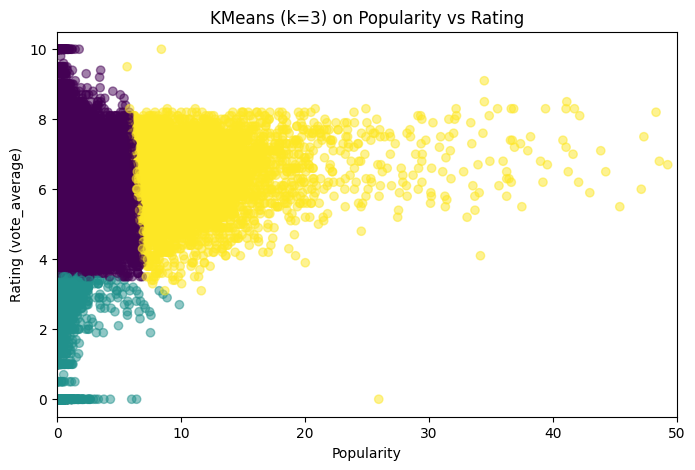

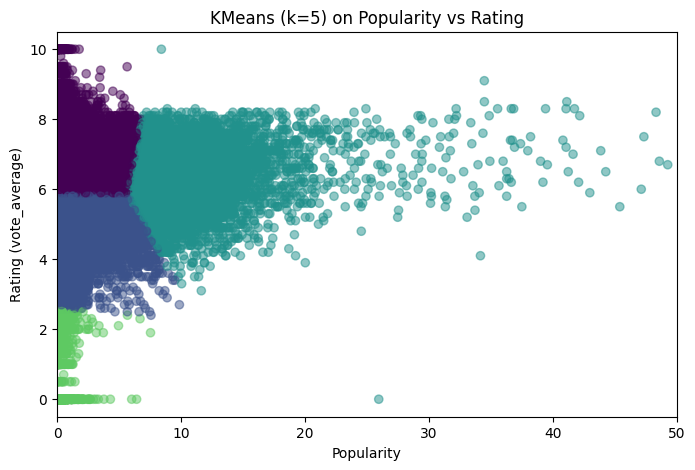

In [320]:
# ===============================
# Plot KMeans results for Combination A
# ===============================

# Plot for k=3
plt.figure(figsize=(8,5))
plt.scatter(
    cluster_A['popularity'],
    cluster_A['vote_average'],
    c=cluster_A['kmeans_A_3'],
    alpha=0.5
)
plt.xlim(0, 50)
plt.xlabel("Popularity")
plt.ylabel("Rating (vote_average)")
plt.title("KMeans (k=3) on Popularity vs Rating")
plt.show()

# Plot for k=5
plt.figure(figsize=(8,5))
plt.scatter(
    cluster_A['popularity'],
    cluster_A['vote_average'],
    c=cluster_A['kmeans_A_5'],
    alpha=0.5
)
plt.xlim(0, 50)
plt.xlabel("Popularity")
plt.ylabel("Rating (vote_average)")
plt.title("KMeans (k=5) on Popularity vs Rating")
plt.show()

KMeans with k=3 separates the data into three main groups based on popularity and rating. One large cluster contains most average movies, while smaller clusters capture low-rated or low-popularity movies. The separation is visible but still quite broad.

With k=5, KMeans creates more refined clusters. The algorithm further separates movies with very low ratings and very high popularity. However, some clusters appear small or less meaningful, suggesting that increasing k too much may lead to over-segmentation.

In [321]:
# ===============================
# KMeans summaries for Combination A
# ===============================

# Cluster sizes for k=3
kmeans_A_3_sizes = cluster_A['kmeans_A_3'].value_counts().sort_index()
kmeans_A_3_sizes_df = kmeans_A_3_sizes.reset_index()
kmeans_A_3_sizes_df.columns = ['Cluster', 'Number of Movies']
kmeans_A_3_sizes_df

,Cluster,Number of Movies
0,0,33868
1,1,4584
2,2,7008


For k=3, one cluster dominates the dataset, containing the majority of movies. The other two clusters are significantly smaller, indicating an imbalance in cluster distribution.

In [322]:
# Average feature values per cluster for k=3
kmeans_A_3_summary = cluster_A.groupby('kmeans_A_3')[features_A].mean().round(2)
kmeans_A_3_summary

,popularity,vote_average
kmeans_A_3,,
0,1.57,6.10
1,0.38,0.94
2,11.14,6.35


- Cluster 0 represents average movies with moderate ratings and low popularity. 
- Cluster 1 contains very low-rated and low-popularity movies. 
- Cluster 2 includes more popular movies with slightly higher ratings, indicating a separation based mainly on popularity.

In [323]:
# Cluster sizes for k=5
kmeans_A_5_sizes = cluster_A['kmeans_A_5'].value_counts().sort_index()
kmeans_A_5_sizes_df = kmeans_A_5_sizes.reset_index()
kmeans_A_5_sizes_df.columns = ['Cluster', 'Number of Movies']
kmeans_A_5_sizes_df

,Cluster,Number of Movies
0,0,20312
1,1,14529
2,2,7056
3,3,3547
4,4,16


For k=5, the data is split into more clusters, but the distribution becomes uneven. One cluster contains very few movies, suggesting the presence of outliers or extreme values.

In [324]:
# Average feature values per cluster for k=5
kmeans_A_5_summary = cluster_A.groupby('kmeans_A_5')[features_A].mean().round(2)
kmeans_A_5_summary

,popularity,vote_average
kmeans_A_5,,
0,1.57,6.83
1,1.50,4.87
2,10.63,6.34
3,0.21,0.29
4,206.56,7.26


The clusters become more specific with k=5. Some clusters capture very low-rated movies, while others isolate highly popular movies. However, the presence of very small clusters suggests that k=5 may be too high for this dataset.

In [325]:
# ===============================
# KMeans on Combination B
# ===============================

# KMeans with k=3
kmeans_B_3 = KMeans(n_clusters=3, random_state=42)
cluster_B['kmeans_B_3'] = kmeans_B_3.fit_predict(scaled_B)

# KMeans with k=5
kmeans_B_5 = KMeans(n_clusters=5, random_state=42)
cluster_B['kmeans_B_5'] = kmeans_B_5.fit_predict(scaled_B)

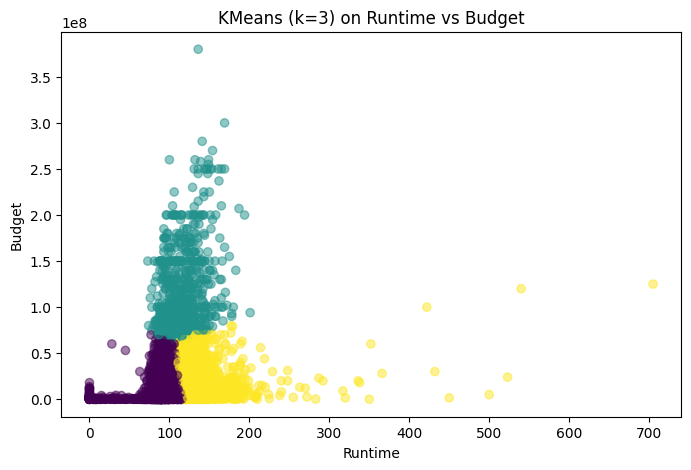

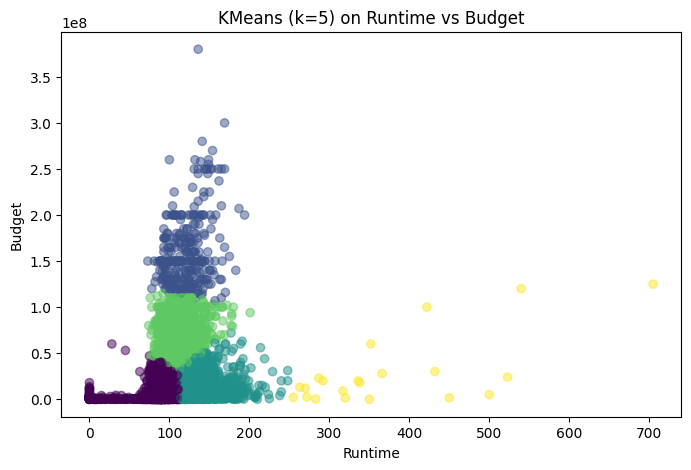

In [326]:
# ===============================
# Plot KMeans results for Combination B
# ===============================

# Plot for k=3
plt.figure(figsize=(8,5))
plt.scatter(
    cluster_B['runtime'],
    cluster_B['budget'],
    c=cluster_B['kmeans_B_3'],
    alpha=0.5
)
plt.xlabel("Runtime")
plt.ylabel("Budget")
plt.title("KMeans (k=3) on Runtime vs Budget")
plt.show()

# Plot for k=5
plt.figure(figsize=(8,5))
plt.scatter(
    cluster_B['runtime'],
    cluster_B['budget'],
    c=cluster_B['kmeans_B_5'],
    alpha=0.5
)
plt.xlabel("Runtime")
plt.ylabel("Budget")
plt.title("KMeans (k=5) on Runtime vs Budget")
plt.show()

KMeans with k=3 groups movies based on budget and runtime into three main clusters. One cluster contains low-budget movies with shorter runtimes, while another captures higher-budget productions. The third cluster represents mid-range movies. The separation is visible but influenced strongly by budget.

With k=5, the clustering becomes more detailed. Additional clusters separate movies with extreme runtimes or very high budgets. However, some clusters appear small and less meaningful, indicating that increasing k may lead to overfitting the data.

In [327]:
# ===============================
# KMeans summaries for Combination B
# ===============================

# Cluster sizes for k=3
kmeans_B_3_sizes = cluster_B['kmeans_B_3'].value_counts().sort_index()
kmeans_B_3_sizes_df = kmeans_B_3_sizes.reset_index()
kmeans_B_3_sizes_df.columns = ['Cluster', 'Number of Movies']
kmeans_B_3_sizes_df

,Cluster,Number of Movies
0,0,6010
1,1,735
2,2,2145


For k=3, one cluster dominates the dataset, while the other two clusters contain fewer movies. This indicates that most movies share similar runtime and budget characteristics, with fewer extreme cases.

In [328]:
# Average feature values per cluster for k=3
kmeans_B_3_summary = cluster_B.groupby('kmeans_B_3')[features_B].mean().round(2)
kmeans_B_3_summary

,runtime,budget
kmeans_B_3,,
0,93.54,1.039234e+07
1,116.01,1.143628e+08
2,134.87,2.123424e+07


- Cluster 0 represents low-budget movies with shorter runtimes. 
- Cluster 1 captures high-budget productions with moderate runtime. 
- Cluster 2 represents longer movies with moderate budgets. This shows that budget is a key factor in separating clusters.

In [329]:
# Cluster sizes for k=5
kmeans_B_5_sizes = cluster_B['kmeans_B_5'].value_counts().sort_index()
kmeans_B_5_sizes_df = kmeans_B_5_sizes.reset_index()
kmeans_B_5_sizes_df.columns = ['Cluster', 'Number of Movies']
kmeans_B_5_sizes_df

,Cluster,Number of Movies
0,0,5475
1,1,286
2,2,1902
3,3,1206
4,4,21


For k=5, the dataset is split into more clusters, but some clusters contain very few movies. This suggests that certain movies with extreme values (very high runtime or budget) are being isolated.

In [330]:
# Average feature values per cluster for k=5
kmeans_B_5_summary = cluster_B.groupby('kmeans_B_5')[features_B].mean().round(2)
kmeans_B_5_summary

,runtime,budget
kmeans_B_5,,
0,92.53,7.920948e+06
1,122.21,1.616957e+08
2,133.07,1.392217e+07
3,111.29,6.248370e+07
4,374.90,2.926452e+07


The clusters become more specialized with k=5. Some clusters isolate high-budget movies, while others capture shorter or longer films. The presence of a very small cluster indicates potential outliers in the dataset.

In [331]:
# ===============================
# DBSCAN on Combination A
# ===============================

# DBSCAN setting 1
dbscan_A_1 = DBSCAN(eps=0.5, min_samples=5)
cluster_A['dbscan_A_1'] = dbscan_A_1.fit_predict(scaled_A)

# DBSCAN setting 2
dbscan_A_2 = DBSCAN(eps=0.8, min_samples=10)
cluster_A['dbscan_A_2'] = dbscan_A_2.fit_predict(scaled_A)

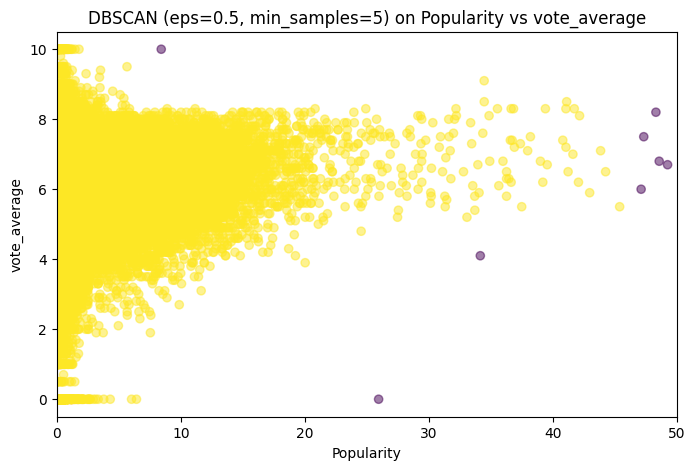

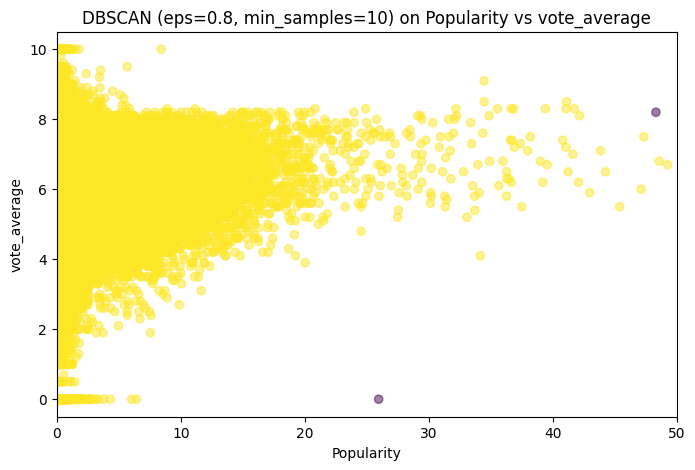

In [332]:
# ===============================
# Plot DBSCAN results for Combination A
# ===============================

# Plot for DBSCAN setting 1
plt.figure(figsize=(8,5))
plt.scatter(
    cluster_A['popularity'],
    cluster_A['vote_average'],
    c=cluster_A['dbscan_A_1'],
    alpha=0.5
)
plt.xlim(0, 50)
plt.xlabel("Popularity")
plt.ylabel("vote_average")
plt.title("DBSCAN (eps=0.5, min_samples=5) on Popularity vs vote_average")
plt.show()

# Plot for DBSCAN setting 2
plt.figure(figsize=(8,5))
plt.scatter(
    cluster_A['popularity'],
    cluster_A['vote_average'],
    c=cluster_A['dbscan_A_2'],
    alpha=0.5
)
plt.xlim(0, 50)
plt.xlabel("Popularity")
plt.ylabel("vote_average")
plt.title("DBSCAN (eps=0.8, min_samples=10) on Popularity vs vote_average")
plt.show()

DBSCAN with eps=0.5 and min_samples=5 identifies almost all movies as belonging to a single cluster. Only a few points are labeled as noise (outliers). This indicates that the data is very dense and DBSCAN is not able to separate meaningful clusters with this parameter setting.

With eps=0.8 and min_samples=10, DBSCAN produces a similar result, grouping nearly all movies into one cluster with very few noise points. Increasing eps makes the clustering even less sensitive to local variations, further reducing the ability to detect distinct groups.

In [333]:
# ===============================
# DBSCAN summaries for Combination A
# ===============================

# Cluster counts for setting 1
dbscan_A_1_counts = cluster_A['dbscan_A_1'].value_counts().sort_index()
dbscan_A_1_counts_df = dbscan_A_1_counts.reset_index()
dbscan_A_1_counts_df.columns = ['Cluster Label', 'Number of Movies']
dbscan_A_1_counts_df

,Cluster Label,Number of Movies
0,-1,45
1,0,45415


The majority of movies are assigned to a single cluster (label 0), while a small number of movies are labeled as -1, representing noise or outliers. This confirms that DBSCAN is not effectively separating the dataset into multiple clusters.

In [334]:
# Cluster counts for setting 2
dbscan_A_2_counts = cluster_A['dbscan_A_2'].value_counts().sort_index()
dbscan_A_2_counts_df = dbscan_A_2_counts.reset_index()
dbscan_A_2_counts_df.columns = ['Cluster Label', 'Number of Movies']
dbscan_A_2_counts_df

,Cluster Label,Number of Movies
0,-1,37
1,0,45423


The results remain similar for the second parameter setting. Almost all movies belong to one cluster, and only a few are considered noise. This suggests that DBSCAN struggles to identify meaningful clusters in this feature space.

In [335]:
# ===============================
# DBSCAN on Combination B
# ===============================

# DBSCAN setting 1
dbscan_B_1 = DBSCAN(eps=0.5, min_samples=5)
cluster_B['dbscan_B_1'] = dbscan_B_1.fit_predict(scaled_B)

# DBSCAN setting 2
dbscan_B_2 = DBSCAN(eps=0.8, min_samples=10)
cluster_B['dbscan_B_2'] = dbscan_B_2.fit_predict(scaled_B)

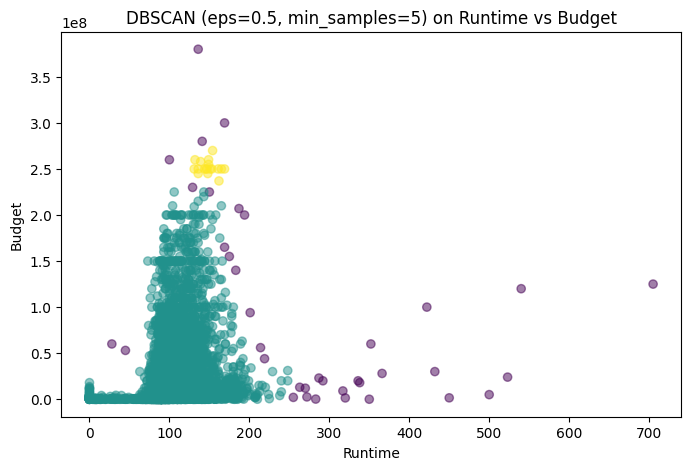

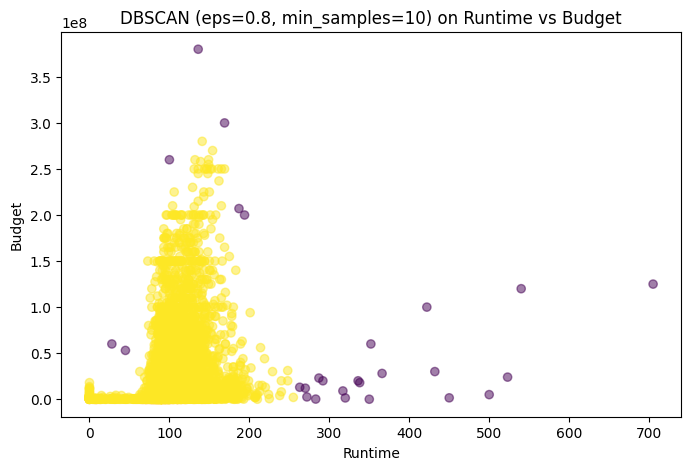

In [336]:
# ===============================
# Plot DBSCAN results for Combination B
# ===============================

# Plot for DBSCAN setting 1
plt.figure(figsize=(8,5))
plt.scatter(
    cluster_B['runtime'],
    cluster_B['budget'],
    c=cluster_B['dbscan_B_1'],
    alpha=0.5
)
plt.xlabel("Runtime")
plt.ylabel("Budget")
plt.title("DBSCAN (eps=0.5, min_samples=5) on Runtime vs Budget")
plt.show()

# Plot for DBSCAN setting 2
plt.figure(figsize=(8,5))
plt.scatter(
    cluster_B['runtime'],
    cluster_B['budget'],
    c=cluster_B['dbscan_B_2'],
    alpha=0.5
)
plt.xlabel("Runtime")
plt.ylabel("Budget")
plt.title("DBSCAN (eps=0.8, min_samples=10) on Runtime vs Budget")
plt.show()

DBSCAN with eps=0.5 and min_samples=5 identifies one main dense cluster of movies with typical runtime and budget values. A small number of movies are separated into a second cluster, while several extreme values (very long runtime or unusual budgets) are labeled as noise.

With eps=0.8 and min_samples=10, DBSCAN groups almost all movies into a single cluster. Only a few points remain classified as noise. Increasing eps reduces the algorithm’s sensitivity, making it less capable of distinguishing separate clusters.

In [337]:
# ===============================
# DBSCAN summaries for Combination B
# ===============================

# Cluster counts for setting 1
dbscan_B_1_counts = cluster_B['dbscan_B_1'].value_counts().sort_index()
dbscan_B_1_counts_df = dbscan_B_1_counts.reset_index()
dbscan_B_1_counts_df.columns = ['Cluster Label', 'Number of Movies']
dbscan_B_1_counts_df

,Cluster Label,Number of Movies
0,-1,37
1,0,8835
2,1,18


The results show that most movies belong to a single cluster, while a small number of movies are classified as noise (-1). A very small second cluster is also detected, indicating a few distinct movies with different runtime or budget characteristics.

In [338]:
# Cluster counts for setting 2
dbscan_B_2_counts = cluster_B['dbscan_B_2'].value_counts().sort_index()
dbscan_B_2_counts_df = dbscan_B_2_counts.reset_index()
dbscan_B_2_counts_df.columns = ['Cluster Label', 'Number of Movies']
dbscan_B_2_counts_df

,Cluster Label,Number of Movies
0,-1,27
1,0,8863


For the second parameter setting, almost all movies are grouped into one cluster, with only a few outliers. This confirms that DBSCAN is not able to form well-separated clusters for this feature combination.

Across both feature combinations, DBSCAN struggled to identify multiple meaningful clusters. The data appears to be dense and continuous rather than forming clearly separated groups, which limits the effectiveness of density-based clustering.

### Comparison of Clustering Algorithms

KMeans and DBSCAN were applied to two different feature combinations. Based on visual inspection, KMeans produced clearer and more interpretable clusters, especially when using k=3. It was able to separate movies into meaningful groups based on popularity, rating, runtime, and budget.

In contrast, DBSCAN struggled to detect distinct clusters. In most cases, it grouped nearly all movies into a single cluster and identified only a few outliers. This suggests that the dataset does not contain well-separated dense regions, which DBSCAN relies on.

Overall, KMeans appears more appropriate for this dataset because it can partition continuous data into meaningful clusters, while DBSCAN is more suitable for datasets with clear density-based structures and noise patterns.

## Study 3 – Content-Based Recommendation System

In [339]:
# ===============================
# Study 3 - Data Preparation
# ===============================

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Create a copy for Study 3
study3_movies = movies.copy()

# Keep only the columns needed for recommendation
study3_movies = study3_movies[[
    'title',
    'genres',
    'runtime',
    'popularity',
    'budget',
    'overview'
]].copy()

# Fill missing text values
study3_movies['title'] = study3_movies['title'].fillna('')
study3_movies['overview'] = study3_movies['overview'].fillna('')

# Convert numeric columns safely
study3_movies['runtime'] = pd.to_numeric(study3_movies['runtime'], errors='coerce')
study3_movies['popularity'] = pd.to_numeric(study3_movies['popularity'], errors='coerce')
study3_movies['budget'] = pd.to_numeric(study3_movies['budget'], errors='coerce')

# Fill missing numeric values with median
study3_movies['runtime'] = study3_movies['runtime'].fillna(study3_movies['runtime'].median())
study3_movies['popularity'] = study3_movies['popularity'].fillna(study3_movies['popularity'].median())
study3_movies['budget'] = study3_movies['budget'].fillna(study3_movies['budget'].median())

# Scale numerical features for fair comparison
scaler = MinMaxScaler()
study3_movies[['runtime_scaled', 'popularity_scaled', 'budget_scaled']] = scaler.fit_transform(
    study3_movies[['runtime', 'popularity', 'budget']]
)

# Keep only movies with non-empty overview for text-based similarity
study3_overview_df = study3_movies[study3_movies['overview'].str.strip() != ''].copy()
study3_overview_df = study3_overview_df.reset_index(drop=True)

# Build TF-IDF matrix on movie overviews
study3_tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
study3_tfidf_matrix = study3_tfidf.fit_transform(study3_overview_df['overview'])

print("Study 3 data prepared.")
print("Movies in study3_movies:", study3_movies.shape)
print("Movies with usable overview:", study3_overview_df.shape)

Study 3 data prepared.
Movies in study3_movies: (45463, 9)
Movies with usable overview: (44504, 9)


### Data Preparation for Study 3

A separate copy of the movie dataset was prepared for the recommendation system. Only the features required for content-based recommendation were kept: title, genres, runtime, popularity, budget, and overview. Missing values were handled, numerical features were scaled, and TF-IDF was applied to the overview text for text-based similarity.

In [340]:
# ===============================
# Study 3 - Helper Functions
# ===============================

def get_movie_row_study3(df, movie_title):
    """
    Return the first matching row for a given movie title.
    """
    matches = df[df['title'] == movie_title]

    if matches.empty:
        raise ValueError(f"Movie '{movie_title}' not found in dataset.")

    return matches.iloc[0]


def numeric_similarity(value1, value2):
    """
    Convert distance between two scaled numeric values into similarity.
    Similarity = 1 - absolute difference
    """
    return 1 - abs(value1 - value2)

In [341]:
# ===============================
# Study 3 - Heuristic 1
# Genre + Runtime + Popularity
# ===============================

def heuristic_1_recommend(df, movie_title, top_n=10):
    """
    Recommend movies using:
    - Jaccard similarity on genres
    - similarity on runtime
    - similarity on popularity

    Final score = average of the three components.
    """

    target = get_movie_row_study3(df, movie_title)
    results = []

    for idx, row in df.iterrows():
        # Skip the target movie itself
        if row['title'] == movie_title:
            continue

        # Compute similarity scores
        genre_score = jaccard_similarity(target['genres'], row['genres'])
        runtime_score = numeric_similarity(target['runtime_scaled'], row['runtime_scaled'])
        popularity_score = numeric_similarity(target['popularity_scaled'], row['popularity_scaled'])

        # Average the three scores
        final_score = (genre_score + runtime_score + popularity_score) / 3

        results.append({
            'title': row['title'],
            'genres': row['genres'],
            'runtime': row['runtime'],
            'popularity': row['popularity'],
            'heuristic_1_score': final_score
        })

    results_df = pd.DataFrame(results)

    # Rank by final score, then by popularity
    results_df = results_df.sort_values(
        by=['heuristic_1_score', 'popularity'],
        ascending=[False, False]
    ).head(top_n)

    return results_df.reset_index(drop=True)

Heuristic 1 combines genre similarity, runtime similarity, and popularity similarity. This heuristic reflects the idea that users may prefer movies that belong to similar genres, have a similar duration, and attract a similar level of audience attention.

In [342]:
# ===============================
# Study 3 - Heuristic 2
# Overview + Budget
# ===============================

def heuristic_2_recommend(movie_title, top_n=10):
    """
    Recommend movies using:
    - cosine similarity on overview
    - similarity on budget

    Final score = average of the two components.
    """

    matches = study3_overview_df[study3_overview_df['title'] == movie_title]

    if matches.empty:
        raise ValueError(f"Movie '{movie_title}' does not have a usable overview.")

    target_idx = matches.index[0]
    target_row = study3_overview_df.iloc[target_idx]

    # Compute cosine similarity between the target overview and all overviews
    overview_scores = cosine_similarity(
        study3_tfidf_matrix[target_idx],
        study3_tfidf_matrix
    ).flatten()

    results = []

    for i, row in study3_overview_df.iterrows():
        # Skip the target movie itself
        if i == target_idx:
            continue

        # Compute budget similarity
        budget_score = numeric_similarity(target_row['budget_scaled'], row['budget_scaled'])

        # Average overview and budget similarities
        final_score = (overview_scores[i] + budget_score) / 2

        results.append({
            'title': row['title'],
            'genres': row['genres'],
            'budget': row['budget'],
            'popularity': row['popularity'],
            'heuristic_2_score': final_score
        })

    results_df = pd.DataFrame(results)

    # Rank by final score, then by popularity
    results_df = results_df.sort_values(
        by=['heuristic_2_score', 'popularity'],
        ascending=[False, False]
    ).head(top_n)

    return results_df.reset_index(drop=True)

Heuristic 2 combines overview similarity and budget similarity. This heuristic reflects the idea that users may prefer movies with similar story content and a similar production scale.

In [343]:
# Request 1 - Toy Story
print("Heuristic 1 - Toy Story")
display(heuristic_1_recommend(study3_movies, "Toy Story"))

print("Heuristic 2 - Toy Story")
display(heuristic_2_recommend("Toy Story"))

Heuristic 1 - Toy Story


,title,genres,runtime,popularity,heuristic_1_score
0,Chicken Little,"[Animation, Family, Comedy]",81.0,18.584609,0.997953
1,Toy Story 2,"[Animation, Comedy, Family]",92.0,17.547693,0.994402
2,"Monsters, Inc.","[Animation, Comedy, Family]",92.0,26.419962,0.994357
3,The Simpsons Movie,"[Animation, Comedy, Family]",87.0,14.302911,0.993754
4,Despicable Me 2,"[Animation, Comedy, Family]",98.0,24.823550,0.993737
5,Chicken Run,"[Animation, Comedy, Family]",84.0,11.834245,0.993047
6,Surf's Up,"[Animation, Comedy, Family]",85.0,11.526339,0.992594
7,Looney Tunes: Back in Action,"[Animation, Comedy, Family]",90.0,13.666488,0.992570
8,Garfield,"[Animation, Comedy, Family]",80.0,10.003679,0.992463
9,An Extremely Goofy Movie,"[Animation, Family, Comedy]",79.0,10.368424,0.992420


Heuristic 2 - Toy Story


,title,genres,budget,popularity,heuristic_2_score
0,The 40 Year Old Virgin,"[Comedy, Romance]",26000000,11.519662,0.729747
1,The Champ,[Drama],0,1.328118,0.682016
2,Andy Kaufman Plays Carnegie Hall,[],0,0.052500,0.669334
3,Superstar: The Life and Times of Andy Warhol,[Documentary],0,0.287500,0.666632
4,Andy Hardy's Blonde Trouble,"[Comedy, Family, Romance]",0,0.512940,0.660644
5,Andy Peters: Exclamation Mark Question Point,[Comedy],0,0.049843,0.659430
6,Wabash Avenue,[Music],2115000,0.109913,0.619849
7,Factory Girl,[Drama],7000000,19.651793,0.616410
8,Class of 1984,"[Action, Drama, Horror, Crime, Thriller]",4300000,4.821182,0.612295
9,Andy Hardy's Private Secretary,"[Comedy, Romance]",0,0.085842,0.611560


Request 1: "Toy Story"

For this request, the two heuristics produce very different types of recommendations.

- **Heuristic 1** returns movies that are strongly aligned in genre (Animation, Family, Comedy) and also similar in runtime and popularity. The results are very consistent and intuitive, including movies such as *Toy Story 2*, *Monsters, Inc.*, and *Despicable Me 2*.

- **Heuristic 2**, on the other hand, returns movies that are not strongly aligned in genre. Instead, it focuses on textual similarity in the overview and budget similarity. As a result, many recommendations (e.g., *The 40 Year Old Virgin*, *Factory Girl*) are less relevant from a family/animation perspective.

Overall, Heuristic 1 provides more relevant recommendations for this request, as genre plays a key role in defining similarity for animated movies.

In [344]:
# Request 2 - Apollo 13
print("Heuristic 1 - Apollo 13")
display(heuristic_1_recommend(study3_movies, "Apollo 13"))

print("Heuristic 2 - Apollo 13")
display(heuristic_2_recommend("Apollo 13"))

Heuristic 1 - Apollo 13


,title,genres,runtime,popularity,heuristic_1_score
0,The Judge,[Drama],141.0,17.887943,0.999203
1,The Perfect Storm,[Drama],130.0,18.911961,0.997254
2,Mommy,[Drama],138.0,14.876086,0.997104
3,Eat Pray Love,[Drama],133.0,15.904834,0.996403
4,Dead Poets Society,[Drama],129.0,19.905716,0.996384
5,Moneyball,[Drama],133.0,15.785663,0.996330
6,The Book Thief,[Drama],131.0,16.373622,0.996158
7,You Don't Know Jack,[Drama],134.0,14.988063,0.996110
8,Showgirls,[Drama],128.0,17.502375,0.996049
9,A Few Good Men,[Drama],138.0,12.330249,0.995554


Heuristic 2 - Apollo 13


,title,genres,budget,popularity,heuristic_2_score
0,The Big Bounce,"[Comedy, Crime]",50000000,6.496271,0.568436
1,Sunshine,"[Science Fiction, Thriller]",50000000,12.715571,0.566839
2,Europa Report,"[Science Fiction, Thriller]",125687,6.964263,0.565673
3,Apollo 13: To the Edge and Back,[Documentary],0,0.002384,0.562936
4,John Rabe,"[Drama, History, War]",20000000,9.154152,0.560363
5,Event Horizon,"[Horror, Science Fiction, Mystery]",60000000,11.335072,0.556916
6,The Hitchhiker's Guide to the Galaxy,"[Adventure, Comedy, Family, Science Fiction]",50000000,13.257255,0.555553
7,Red Planet,"[Thriller, Action, Science Fiction]",80000000,8.534176,0.552786
8,American Wedding,"[Comedy, Romance]",55000000,14.397139,0.552746
9,Sergeant Dead Head,[Comedy],0,0.005905,0.548736


Request 2: "Apollo 13"

For this request, the two heuristics again show different behaviors.

- **Heuristic 1** mainly returns drama movies with similar runtime and popularity. The results are highly consistent in genre, but they do not necessarily reflect thematic similarity related to space or real events.

- **Heuristic 2** produces more diverse results, including science fiction and space-related movies such as *Sunshine* and *Europa Report*. This suggests that the overview-based similarity is capturing thematic elements better than metadata alone.

In this case, Heuristic 2 appears to provide more meaningful recommendations because it captures the theme of space exploration, whereas Heuristic 1 focuses more on general movie characteristics.

In [345]:
# Request 3 - Fight Club
print("Heuristic 1 - Fight Club")
display(heuristic_1_recommend(study3_movies, "Fight Club"))

print("Heuristic 2 - Fight Club")
display(heuristic_2_recommend("Fight Club"))

Heuristic 1 - Fight Club


,title,genres,runtime,popularity,heuristic_1_score
0,Whiplash,[Drama],105.0,64.299990,0.990715
1,One Flew Over the Cuckoo's Nest,[Drama],133.0,35.529554,0.981153
2,Creed,[Drama],133.0,33.449723,0.979887
3,Apollo 13,[Drama],140.0,18.761467,0.972271
4,The Judge,[Drama],141.0,17.887943,0.971474
5,Dead Poets Society,[Drama],129.0,19.905716,0.970579
6,The Perfect Storm,[Drama],130.0,18.911961,0.970239
7,Seven Pounds,[Drama],123.0,21.708267,0.970084
8,Mommy,[Drama],138.0,14.876086,0.969905
9,American Beauty,[Drama],122.0,20.726578,0.969221


Heuristic 2 - Fight Club


,title,genres,budget,popularity,heuristic_2_score
0,Astérix and Obélix: God Save Britannia,"[Family, Adventure, Comedy]",61000000,9.722726,0.559934
1,The Boxtrolls,"[Animation, Comedy, Family, Fantasy]",60000000,11.563909,0.550965
2,Austin Powers in Goldmember,"[Comedy, Crime, Science Fiction]",63000000,8.786653,0.543010
3,ParaNorman,"[Family, Animation, Adventure, Comedy]",60000000,10.425038,0.542388
4,Anchorman 2: The Legend Continues,[Comedy],50000000,7.600751,0.539468
5,Forces of Nature,"[Romance, Comedy]",75000000,7.906035,0.538495
6,Junior,"[Comedy, Family, Romance]",60000000,6.710215,0.537733
7,Reign of Fire,"[Adventure, Action, Fantasy]",60000000,13.067306,0.535803
8,Any Given Sunday,[Drama],55000000,10.571434,0.534232
9,The Matrix,"[Action, Science Fiction]",63000000,33.366332,0.534075


Request 3: "Fight Club"

The results for this request highlight a clear difference between the two heuristics.

- **Heuristic 1** returns mostly drama movies with similar runtime and popularity, such as *Whiplash* and *American Beauty*. While these are critically similar films, they do not necessarily match the unique psychological and thematic elements of *Fight Club*.

- **Heuristic 2** returns a mix of movies based on overview similarity and budget, but many of the results are not strongly related in theme (e.g., *Anchorman 2*, *The Matrix* appears but lower relevance contextually).

Neither heuristic perfectly captures the unique nature of *Fight Club*, but Heuristic 1 provides more consistent results, while Heuristic 2 is more unpredictable due to reliance on textual similarity.

### Overall Qualitative Comparison

The two heuristics produce different recommendation patterns because they rely on different definitions of similarity.

- **Heuristic 1 (Genre + Runtime + Popularity)**:
  - Produces consistent and structured results
  - Strongly respects genre similarity
  - Works well when genre is important (e.g., Toy Story)
  - May fail to capture deeper thematic meaning

- **Heuristic 2 (Overview + Budget)**:
  - Captures thematic similarity through text
  - Produces more diverse and sometimes unexpected results
  - Can better identify story-related similarities (e.g., Apollo 13)
  - Less consistent due to noisy or sparse text data

Overall, Heuristic 1 provides more stable and intuitive recommendations, while Heuristic 2 can sometimes provide more interesting but less reliable results. This confirms that content-based recommendation is subjective and depends heavily on how similarity is defined.

## Study 4 - Collaborative Filtering Recommendation System

In [346]:
# ===============================
# Study 4 - Data Preparation
# ===============================

import numpy as np
import pandas as pd
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_squared_error

# Use only the ratings data for collaborative filtering
study4_ratings = ratings.copy()

# Keep only necessary columns
study4_ratings = study4_ratings[['userId', 'movieId', 'rating']].copy()

# Ensure correct types
study4_ratings['userId'] = pd.to_numeric(study4_ratings['userId'], errors='coerce')
study4_ratings['movieId'] = pd.to_numeric(study4_ratings['movieId'], errors='coerce')
study4_ratings['rating'] = pd.to_numeric(study4_ratings['rating'], errors='coerce')

# Drop rows with missing values
study4_ratings = study4_ratings.dropna()

# Convert ids to integers
study4_ratings['userId'] = study4_ratings['userId'].astype(int)
study4_ratings['movieId'] = study4_ratings['movieId'].astype(int)

print("Study 4 ratings shape:", study4_ratings.shape)
display(study4_ratings.head())

Study 4 ratings shape: (100004, 3)


,userId,movieId,rating
0,1,31,2.5
1,1,1029,3.0
2,1,1061,3.0
3,1,1129,2.0
4,1,1172,4.0


For collaborative filtering, only the user ratings data is used. The recommendation process does not rely on movie metadata. Therefore, the ratings dataset was cleaned and reduced to the three required fields: userId, movieId, and rating.

In [347]:
# ===============================
# Study 4 - Gold Standard Split
# ===============================

# Create gold standard by sampling about 10% of ratings per user
gold_standard_parts = []
train_parts = []

for user_id, group in study4_ratings.groupby('userId'):
    # Number of ratings to hold out for this user
    n_holdout = max(1, int(round(len(group) * 0.10)))
    
    # Sample gold standard ratings for this user
    gs_part = group.sample(n=n_holdout, random_state=42)
    
    # Remaining ratings go to training
    train_part = group.drop(gs_part.index)
    
    gold_standard_parts.append(gs_part)
    train_parts.append(train_part)

study4_gold_standard = pd.concat(gold_standard_parts).reset_index(drop=True)
study4_train = pd.concat(train_parts).reset_index(drop=True)

print("Training set shape:", study4_train.shape)
print("Gold Standard shape:", study4_gold_standard.shape)
print("Gold Standard percentage:", round(len(study4_gold_standard) / len(study4_ratings) * 100, 2), "%")

Training set shape: (90013, 3)
Gold Standard shape: (9991, 3)
Gold Standard percentage: 9.99 %


### Gold Standard Split

To evaluate the collaborative filtering model, the ratings data was split into a training set and a Gold Standard set. For each user, about 10% of their ratings were randomly removed and placed into the Gold Standard. This ensures that the held-out ratings are distributed across all users rather than concentrated among only a few users.

In this case:
- the **training set** contains **90013 ratings**
- the **Gold Standard** contains **9991 ratings**
- the held-out data represents **9.99%** of the full ratings dataset

This Gold Standard is later used to compare predicted ratings against true ratings.

In [348]:
# ===============================
# Study 4 - Utility Matrix
# ===============================

# Build user-item utility matrix from training ratings
study4_utility = study4_train.pivot(index='userId', columns='movieId', values='rating').fillna(0)

print("Utility matrix shape:", study4_utility.shape)
display(study4_utility.iloc[:5, :5])

Utility matrix shape: (671, 8770)


movieId,1,2,3,4,5
userId,,,,,
1,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0


### Utility Matrix

The utility matrix was built from the training ratings only. In this matrix:
- each **row** represents a **user**
- each **column** represents a **movie**
- each **cell** contains the rating given by that user to that movie

The resulting matrix has shape **(671, 8770)**, meaning:
- **671 users**
- **8770 movies**

Missing ratings were filled with **0**, which indicates that the user has not rated that movie in the training data. This matrix is the basis for matrix factorization in the next step.

In [349]:
# ===============================
# Study 4 - Matrix Factorization
# ===============================

# Convert utility matrix to numpy array
R = study4_utility.values

# Choose latent dimensions
k = 20

# Apply truncated SVD
U, sigma, Vt = svds(R, k=k)

# Convert sigma into diagonal matrix
sigma = np.diag(sigma)

# Reconstruct predicted ratings matrix
R_pred = np.dot(np.dot(U, sigma), Vt)

# Convert predictions back to DataFrame
study4_pred_df = pd.DataFrame(
    R_pred,
    index=study4_utility.index,
    columns=study4_utility.columns
)

print("Predicted ratings matrix shape:", study4_pred_df.shape)

Predicted ratings matrix shape: (671, 8770)


Matrix factorization was applied using truncated SVD with k=20 latent factors. This decomposes the utility matrix into lower-dimensional representations and reconstructs predicted ratings for all user-item pairs.

In [350]:
# ===============================
# Study 4 - Recommendation Function
# ===============================

def get_unseen_recommendations(user_id, pred_df, train_df, movies_df, top_n=10):
    """
    Recommend top unseen movies for a given user based on predicted ratings.
    Only return movies that exist in the metadata table.
    """
    
    # Movies already rated by the user in training
    seen_movies = train_df[train_df['userId'] == user_id]['movieId'].tolist()
    
    # Predicted scores for all movies for this user
    user_predictions = pred_df.loc[user_id].copy()
    
    # Keep only unseen movies
    unseen_predictions = user_predictions[~user_predictions.index.isin(seen_movies)]
    
    # Keep only movie IDs that exist in the metadata
    valid_movie_ids = movies_df['id'].dropna().astype(int).unique()
    unseen_predictions = unseen_predictions[unseen_predictions.index.isin(valid_movie_ids)]
    
    # Get top predicted unseen movies
    top_movie_ids = unseen_predictions.sort_values(ascending=False).head(top_n)
    
    # Build recommendation table
    recommended = pd.DataFrame({
        'movieId': top_movie_ids.index,
        'predicted_rating': top_movie_ids.values
    })
    
    # Merge with movie metadata
    recommended = recommended.merge(
        movies_df[['id', 'title', 'genres', 'popularity']],
        left_on='movieId',
        right_on='id',
        how='inner'
    )
    
    # Keep only useful columns
    recommended = recommended[['movieId', 'title', 'genres', 'popularity', 'predicted_rating']]
    
    return recommended.reset_index(drop=True)

In [351]:
# ===============================
# Study 4 - Simulated Requests
# ===============================

# Choose 3 users for recommendation examples
study4_users = [1, 10, 50]

In [352]:
# =====================
# Fix movie ID mismatch 
# =====================

# Ensure consistent movie IDs for merging
movies['id'] = pd.to_numeric(movies['id'], errors='coerce')

# Drop rows where id is missing
movies = movies.dropna(subset=['id'])

# Convert to int
movies['id'] = movies['id'].astype(int)

Recommendations are generated using predicted ratings obtained from matrix factorization. For each user, movies that have not been previously rated are ranked based on predicted scores, and the Top 10 unseen movies are returned.

In [353]:
# Request 1
print("Top unseen movie recommendations for User 1")
display(get_unseen_recommendations(1, study4_pred_df, study4_train, movies, top_n=10))

Top unseen movie recommendations for User 1


,movieId,title,genres,popularity,predicted_rating
0,1387,Superstar: The Karen Carpenter Story,"[Drama, Music]",0.640356,0.175842
1,1252,Lonely Hearts,"[Drama, Thriller, Crime, Romance]",5.694413,0.149144
2,1374,Rocky IV,[Drama],10.257210,0.148699
3,913,The Thomas Crown Affair,"[Drama, Crime, Romance]",10.961226,0.145016
4,1278,The Dreamers,"[Drama, Romance]",6.685981,0.136711
5,1262,Stranger Than Fiction,"[Comedy, Drama, Fantasy, Romance]",10.798092,0.131370
6,1266,Street Kings,"[Action, Crime, Drama, Thriller]",13.246795,0.128904
7,1282,Dogtown and Z-Boys,[Documentary],4.704091,0.127512
8,1090,The Thirteenth Floor,"[Thriller, Science Fiction, Mystery]",9.356587,0.126347
9,923,Dawn of the Dead,[Horror],19.242010,0.125960


In [354]:
# Request 2
print("Top unseen movie recommendations for User 10")
display(get_unseen_recommendations(10, study4_pred_df, study4_train, movies, top_n=10))

Top unseen movie recommendations for User 10


,movieId,title,genres,popularity,predicted_rating
0,260,The 39 Steps,"[Action, Thriller, Mystery]",5.865697,1.730239
1,2028,Say Anything...,"[Comedy, Drama, Romance]",6.953646,0.965646
2,4993,5 Card Stud,"[Action, Western, Thriller]",1.372254,0.823303
3,296,Terminator 3: Rise of the Machines,"[Action, Thriller, Science Fiction]",20.818907,0.816105
4,1259,Notes on a Scandal,"[Drama, Romance]",8.593087,0.788726
5,541,The Man with the Golden Arm,"[Crime, Drama, Romance]",3.353068,0.773311
6,593,Solaris,"[Drama, Science Fiction, Adventure, Mystery]",11.059785,0.762882
7,858,Sleepless in Seattle,"[Comedy, Drama, Romance]",10.234919,0.738904
8,608,Men in Black II,"[Action, Adventure, Comedy, Science Fiction]",16.775716,0.730449
9,527,Once Were Warriors,[Drama],4.025276,0.729377


In [355]:
# Request 3
print("Top unseen movie recommendations for User 50")
display(get_unseen_recommendations(50, study4_pred_df, study4_train, movies, top_n=10))

Top unseen movie recommendations for User 50


,movieId,title,genres,popularity,predicted_rating
0,480,Monsoon Wedding,"[Comedy, Drama, Romance]",10.625504,2.573983
1,593,Solaris,"[Drama, Science Fiction, Adventure, Mystery]",11.059785,2.479270
2,318,The Million Dollar Hotel,"[Drama, Thriller]",4.938231,2.334910
3,592,The Conversation,"[Crime, Drama, Mystery]",13.245638,2.304601
4,364,Batman Returns,"[Action, Fantasy]",15.001681,2.107483
5,588,Silent Hill,"[Horror, Mystery]",7.938457,1.908126
6,595,To Kill a Mockingbird,"[Crime, Drama]",14.284787,1.716353
7,500,Reservoir Dogs,"[Crime, Thriller]",12.220340,1.681279
8,329,Jurassic Park,"[Adventure, Science Fiction]",8.863776,1.630980
9,153,Lost in Translation,[Drama],11.609441,1.460447


In [356]:
# ===============================
# Study 4 - Evaluation 1: MSE
# ===============================

# Keep only GS rows that exist in prediction matrix
gs_eval = study4_gold_standard[
    study4_gold_standard['userId'].isin(study4_pred_df.index) &
    study4_gold_standard['movieId'].isin(study4_pred_df.columns)
].copy()

# Get predicted scores for GS entries
gs_eval['predicted_rating'] = gs_eval.apply(
    lambda row: study4_pred_df.loc[row['userId'], row['movieId']],
    axis=1
)

# Compute MSE
study4_mse = mean_squared_error(gs_eval['rating'], gs_eval['predicted_rating'])

print("Study 4 - MSE:", round(study4_mse, 4))

Study 4 - MSE: 8.6798


In [357]:
# ===============================
# Study 4 - Evaluation 2: P@5, P@10, MRR
# ===============================

# Transform GS ratings into binary relevance
gs_eval['relevant'] = gs_eval['rating'].apply(lambda x: 1 if x >= 4 else 0)

def precision_at_k(relevance_list, k):
    """
    Compute Precision@K from a ranked binary relevance list.
    """
    if len(relevance_list) == 0:
        return 0
    return sum(relevance_list[:k]) / k

def reciprocal_rank(relevance_list):
    """
    Compute Reciprocal Rank from a ranked binary relevance list.
    """
    for idx, rel in enumerate(relevance_list, start=1):
        if rel == 1:
            return 1 / idx
    return 0

# Compute metrics user by user on GS items
p5_scores = []
p10_scores = []
rr_scores = []

for user_id, user_group in gs_eval.groupby('userId'):
    # Rank this user's GS items by predicted score
    ranked_user = user_group.sort_values(by='predicted_rating', ascending=False)
    relevance_list = ranked_user['relevant'].tolist()
    
    p5_scores.append(precision_at_k(relevance_list, 5))
    p10_scores.append(precision_at_k(relevance_list, 10))
    rr_scores.append(reciprocal_rank(relevance_list))

study4_p5 = np.mean(p5_scores)
study4_p10 = np.mean(p10_scores)
study4_mrr = np.mean(rr_scores)

print("Study 4 - Precision@5:", round(study4_p5, 4))
print("Study 4 - Precision@10:", round(study4_p10, 4))
print("Study 4 - MRR:", round(study4_mrr, 4))

Study 4 - Precision@5: 0.5618
Study 4 - Precision@10: 0.4227
Study 4 - MRR: 0.82


### Study 4 Results and Discussion

The collaborative filtering recommendation system was implemented using matrix factorization (SVD) on the user-item utility matrix.

From the quantitative evaluation:

- The **MSE (8.6798)** indicates that there is some prediction error, which is expected due to the sparsity of the dataset and the use of a low-dimensional latent factor model.
- The **Precision@5 (0.5618)** shows that more than half of the top 5 recommended movies are relevant, indicating good recommendation performance.
- The **Precision@10 (0.4227)** decreases as more items are considered, which is expected since lower-ranked recommendations are generally less relevant.
- The **MRR (0.82)** is high, meaning that relevant items tend to appear early in the ranked recommendation list.

From a qualitative perspective, the recommendations generated for users are consistent with patterns in user rating behavior. The model is able to suggest movies that users are likely to enjoy based on similarities with other users, even when the movies are not obviously related in genre or content.

Overall, collaborative filtering provides an effective recommendation strategy and complements the content-based approach from Study 3 by leveraging user interaction data instead of movie metadata.

## Conclusion

In this assignment, multiple data science techniques were applied to analyze and recommend movies using different approaches.

In **Study 1**, various similarity measures were implemented to compare movies based on different attributes such as genre, runtime, budget, overview, and title. This demonstrated how similarity can be defined in multiple ways depending on the chosen features.

In **Study 2**, clustering techniques (KMeans and DBSCAN) were used to identify patterns in the dataset. KMeans produced clearer and more interpretable clusters, while DBSCAN struggled due to the lack of strong density separation in the data.

In **Study 3**, a content-based recommendation system was developed using two different heuristics. The results showed that recommendations depend heavily on how similarity is defined, highlighting the subjective nature of content-based filtering.

In **Study 4**, a collaborative filtering recommendation system was implemented using matrix factorization. This approach leveraged user rating behavior rather than movie metadata, allowing the model to uncover hidden user preferences. Quantitative evaluation using MSE, Precision@5, Precision@10, and MRR demonstrated that the model can provide relevant recommendations.

Overall, the assignment illustrates that different recommendation approaches have different strengths. Content-based methods rely on item features, while collaborative filtering leverages user behavior. Combining both approaches could lead to even more effective recommendation systems.

## References

- Banik, R. (2017). *The Movies Dataset*. Kaggle.  
  Available at: https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset

- OpenAI. (2025). *ChatGPT (GPT-5.3)*.  
  Used as an AI assistant to support understanding of concepts, code structuring, and debugging throughout the assignment.  
  Available at: https://openai.com/chatgpt